# 🧠 Módulo 00: Pensamiento Tensorial para Algoritmistas
## Desmitificando los Tensores: Memoria Plana, Strides y Broadcasting en O(1)

> *"En hardware real no existen matrices ni tensores multidimensionales; solo existe un puntero de memoria a un buffer contiguo de 1D y la aritmética de punteros que inventamos para recorrerlo."*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mcarbonell/algo-to-ai/blob/main/notebooks/00_foundations/00_tensor_thinking.ipynb)

---

### ⚙️ Inicialización del Entorno
Ejecuta la siguiente celda para asegurarte de que el entorno dispone de las librerías necesarias.

In [1]:
# Instalación opcional en caso de ejecutar en Colab limpio
# !pip install -q numpy matplotlib torch

import sys
import time
from typing import Tuple, List, Union
import numpy as np
import matplotlib.pyplot as plt
import torch

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print("Dispositivo disponible en PyTorch:", "GPU / Acelerador" if torch.cuda.is_available() else "CPU")

Python: 3.13.15
NumPy: 2.1.3
PyTorch: 2.11.0+cu128
Dispositivo disponible en PyTorch: GPU / Acelerador


---

## 1. 📜 Contexto Histórico y Proceso de Descubrimiento

### De los Arrays de Fortran al Muro de la Memoria
En los inicios de la computación científica en los años 60 y 70, librerías como **BLAS** (Basic Linear Algebra Subprograms) y **LAPACK** revolucionaron el cálculo definiendo cómo multiplicar matrices en hardware estructurado. Sin embargo, estas librerías trataban casi exclusivamente con vectores (1D) y matrices rectangulares (2D).

Con la llegada de las redes neuronales y el procesamiento de imágenes en los 90 y 2000, los programadores se encontraron de repente con estructuras de datos de $4, 5$ o más dimensiones:
* **Visión:** `[Batch, Canales, Altura, Anchura]` (4D)
* **Transformers:** `[Batch, Secuencia, Cabezas, Dimensión]` (4D)
* **Vídeo:** `[Batch, Frames, Canales, Altura, Anchura]` (5D)

### El error ingenuo que casi detiene el Deep Learning
Al principio, muchos programadores representaban estas estructuras como listas anidadas de punteros (`vector<vector<vector<float>>>` o listas de Python). Esto era catastrófico:
1. **Punteros dispersos:** Cada fila estaba en una dirección aleatoria de la memoria RAM.
2. **Destrucción de la Jerarquía de Caché:** Las CPUs y GPUs dependen críticamente de leer bloques contiguos de memoria (líneas de caché L1/L2/L3 y ráfagas de memoria HBM/DRAM).
3. **Coste desmesurado de transposición:** Si querías cambiar los ejes de un tensor de `[Batch, Time, Features]` a `[Time, Batch, Features]`, tenías que reservar un nuevo bloque de memoria de gigabytes y copiar cada número uno a uno ($O(N)$ en tiempo y memoria).

### El momento Eureka: Strides y Vistas Desacopladas
A principios de los 2000, los arquitectos de **NumPy** (formalizado por Travis Oliphant y Stefan van der Walt en 2006-2011) generalizaron una abstracción elegante tomada de la computación de arrays multidimensionales: **separar el almacenamiento de datos (`Storage`) de la metadata de indexación (`Shape` y `Strides`)**.

Gracias a esto:
* Transponer cualquier tensor de $N$ dimensiones pasó de costar $O(N)$ copias de memoria a **$O(1)$ en tiempo y $0$ bytes de memoria adicional**.
* El concepto de **Broadcasting** permitió operar entre tensores de distinto tamaño sin duplicar un solo byte en memoria física, simplemente configurando un stride igual a $0$.

---

## 2. 🧠 Intuición Geométrica y Mecánica (Mentalidad de Algoritmista)

### La Realidad del Hardware: Todo es 1D
Tu ordenador **no tiene memoria bidimensional**. La memoria RAM y la memoria de una GPU (VRAM) son únicamente un array gigantesco de bytes lineales contiguos, direccionados desde la dirección `0x00000000` hasta el final.

Cuando defines una matriz de $3 \times 4$ de números flotantes de 32 bits (4 bytes):
```
Lógica (2D):                      Física (RAM 1D):
[[ 0,  1,  2,  3],        ->      [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
 [ 4,  5,  6,  7],
 [ 8,  9, 10, 11]]
```

### La Ecuación Maestra del Stride
¿Cómo sabe el sistema en qué dirección de memoria lineal está el elemento lógico $(i, j)$?
Mediante la fórmula del **stride** (paso):

$$\text{Offset 1D} = \text{offset\_base} + \sum_{k=0}^{D-1} i_k \cdot \text{stride}_k$$

Para una matriz $2D$ de tamaño $(R, C)$ en formato estándar C-contiguous:
* $\text{stride}_0 = C$ (para avanzar una fila, saltamos $C$ elementos en el buffer lineal).
* $\text{stride}_1 = 1$ (para avanzar una columna, saltamos $1$ elemento en el buffer lineal).

Visualicemos este mapeo interactivo a continuación:

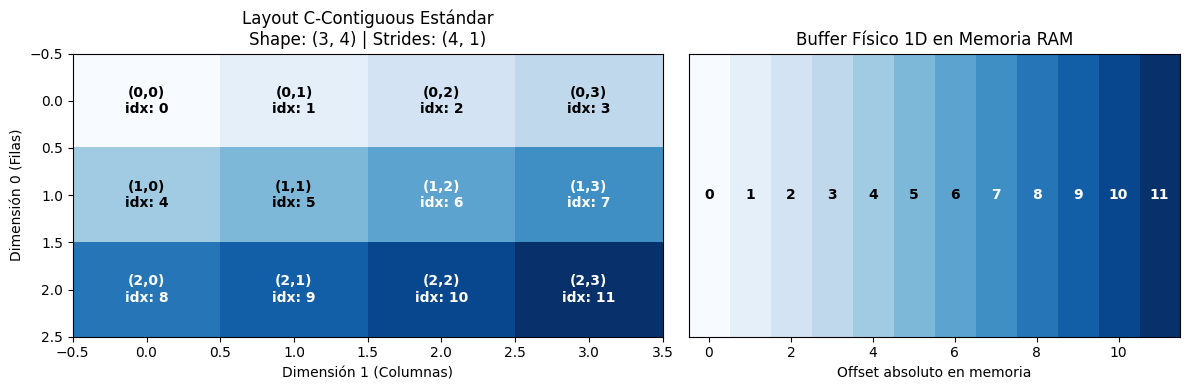

In [2]:
def visualizar_layout_2d(shape=(3, 4), strides=(4, 1), titulo="Layout C-Contiguous Estándar"):
    rows, cols = shape
    grid = np.zeros((rows, cols), dtype=int)
    for r in range(rows):
        for c in range(cols):
            grid[r, c] = r * strides[0] + c * strides[1]
            
    fig, (ax_2d, ax_1d) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [1.2, 1]})
    
    # Vista 2D Lógica
    cax = ax_2d.imshow(grid, cmap="Blues", aspect="auto")
    for r in range(rows):
        for c in range(cols):
            ax_2d.text(c, r, f"({r},{c})\nidx: {grid[r, c]}", ha='center', va='center',
                       color='white' if grid[r, c] > grid.max() / 2 else 'black', fontweight='bold')
    ax_2d.set_title(f"{titulo}\nShape: {shape} | Strides: {strides}")
    ax_2d.set_xlabel("Dimensión 1 (Columnas)")
    ax_2d.set_ylabel("Dimensión 0 (Filas)")
    
    # Vista 1D Física del Buffer
    buffer_len = grid.max() + 1
    buffer_view = np.arange(buffer_len).reshape(1, -1)
    ax_1d.imshow(buffer_view, cmap="Blues", aspect="auto")
    for idx in range(buffer_len):
        ax_1d.text(idx, 0, str(idx), ha='center', va='center', fontweight='bold',
                   color='white' if idx > buffer_len / 2 else 'black')
    ax_1d.set_title("Buffer Físico 1D en Memoria RAM")
    ax_1d.set_yticks([])
    ax_1d.set_xlabel("Offset absoluto en memoria")
    
    plt.tight_layout()
    plt.show()

# Ejecutar la visualización con strides estándar (4, 1)
visualizar_layout_2d((3, 4), (4, 1))

### La Magia de la Transposición en $O(1)$
¿Qué ocurre si queremos transponer la matriz (convertir $(3, 4)$ en $(4, 3)$)?

* **Enfoque ingenuo:** Crear un nuevo buffer de 12 elementos y copiar los datos.
* **Enfoque de strides:** Simplemente **intercambiamos los strides**:
  * Nuevo shape: `(4, 3)`
  * Nuevos strides: `(1, 4)`

¡Los datos en memoria no se han movido ni un milímetro! Observemos la gráfica con los strides invertidos:

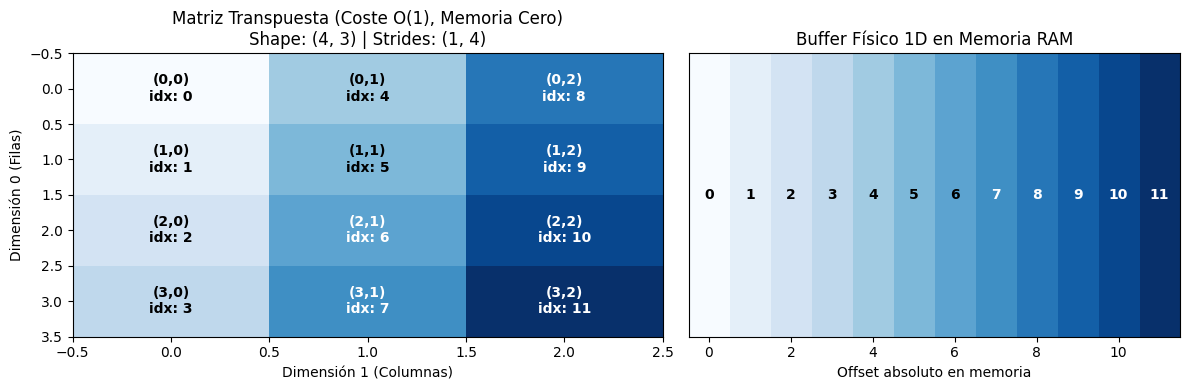

In [3]:
# Transpuesta virtual: shape invertido (4, 3) y strides intercambiados (1, 4)
visualizar_layout_2d(shape=(4, 3), strides=(1, 4), titulo="Matriz Transpuesta (Coste O(1), Memoria Cero)")

---

## 3. 🛠️ Implementación "From Scratch" (Primeros Principios)

Vamos a construir nuestra propia clase `MiniTensor` en Python puro. No utilizaremos matrices multidimensionales de NumPy; almacenaremos los datos en una lista plana de 1D y resolveremos toda la geometría con aritmética de strides.

In [4]:
class MiniTensor:
    """
    Tensor multidimensional implementado desde primeros principios sobre un buffer plano 1D.
    Demuestra el funcionamiento de Shapes, Strides, Vistas, Transposiciones y Broadcasting.
    """
    def __init__(
        self,
        data: List[float],
        shape: Tuple[int, ...],
        strides: Tuple[int, ...] = None,
        offset: int = 0
    ):
        self.storage = data  # Buffer 1D contiguo
        self.shape = tuple(shape)
        self.offset = offset
        
        # Si no se pasan strides, calculamos el layout C-contiguous por defecto
        if strides is None:
            self.strides = self._compute_c_strides(self.shape)
        else:
            self.strides = tuple(strides)
            
    @staticmethod
    def _compute_c_strides(shape: Tuple[int, ...]) -> Tuple[int, ...]:
        """
        Calcula los strides estándar en orden fila-mayor (C-contiguous).
        stride[k] = producto(shape[k+1:]) con stride[-1] = 1.
        """
        if not shape:
            return ()
        strides = [1] * len(shape)
        for k in range(len(shape) - 2, -1, -1):
            strides[k] = strides[k + 1] * shape[k + 1]
        return tuple(strides)

    def __getitem__(self, indices: Union[int, Tuple[int, ...]]) -> float:
        """
        Calcula la dirección lineal en el buffer usando la fórmula maestra del stride.
        """
        if isinstance(indices, int):
            indices = (indices,)
            
        assert len(indices) == len(self.shape), f"Se esperaban {len(self.shape)} índices, pero se pasaron {len(indices)}"
        
        linear_idx = self.offset
        for idx, stride, dim_size in zip(indices, self.strides, self.shape):
            assert 0 <= idx < dim_size, f"Índice {idx} fuera de límites para dimensión de tamaño {dim_size}"
            linear_idx += idx * stride
            
        return self.storage[linear_idx]

    def transpose(self, dim0: int = 0, dim1: int = 1) -> 'MiniTensor':
        """
        Transpone dos dimensiones en O(1) tiempo y O(1) memoria (sin copiar el buffer).
        """
        new_shape = list(self.shape)
        new_strides = list(self.strides)
        
        # Intercambiar dimensiones y strides
        new_shape[dim0], new_shape[dim1] = new_shape[dim1], new_shape[dim0]
        new_strides[dim0], new_strides[dim1] = new_strides[dim1], new_strides[dim0]
        
        # Retorna una nueva 'Vista' apuntando exactamente al mismo buffer de memoria
        return MiniTensor(self.storage, tuple(new_shape), tuple(new_strides), self.offset)

    def broadcast_to(self, new_shape: Tuple[int, ...]) -> 'MiniTensor':
        """
        Expande dimensiones unitarias fijando su stride a 0.
        ¡Cero duplicación de datos en memoria!
        """
        new_strides = list(self.strides)
        # Adaptar dimensiones si new_shape tiene mayor rango
        diff = len(new_shape) - len(self.shape)
        current_shape = (1,) * diff + self.shape
        new_strides = [0] * diff + new_strides
        
        final_strides = []
        for old_dim, new_dim, st in zip(current_shape, new_shape, new_strides):
            if old_dim == new_dim:
                final_strides.append(st)
            elif old_dim == 1:
                # La dimensión se expande virtualmente: stride 0 para no avanzar en memoria
                final_strides.append(0)
            else:
                raise ValueError(f"No se puede hacer broadcast de dimensión {old_dim} a {new_dim}")
                
        return MiniTensor(self.storage, new_shape, tuple(final_strides), self.offset)

    def to_contiguous(self) -> 'MiniTensor':
        """
        Si el tensor no es contiguo, compacta los datos creando un nuevo buffer contiguo en memoria.
        """
        # Generar todos los elementos en orden lógico
        flat_data = []
        
        def _recurse(dim: int, current_indices: list):
            if dim == len(self.shape):
                flat_data.append(self[tuple(current_indices)])
                return
            for i in range(self.shape[dim]):
                current_indices.append(i)
                _recurse(dim + 1, current_indices)
                current_indices.pop()
                
        _recurse(0, [])
        return MiniTensor(flat_data, self.shape)

    def to_list(self) -> list:
        """Representación anidada legible para inspección."""
        def _build(dim: int, prefix_idx: list):
            if dim == len(self.shape) - 1:
                return [self[tuple(prefix_idx + [k])] for k in range(self.shape[dim])]
            return [_build(dim + 1, prefix_idx + [k]) for k in range(self.shape[dim])]
        return _build(0, [])

print("✅ Clase MiniTensor compilada correctamente")

✅ Clase MiniTensor compilada correctamente


### Demostración Práctica del MiniTensor
Probemos cómo se comporta nuestra implementación con una matriz de $2 \times 3$:

In [5]:
# Buffer de 6 números contiguos
buffer_plano = [10.0, 20.0, 30.0, 40.0, 50.0, 60.0]

# Matriz 2x3
t = MiniTensor(buffer_plano, shape=(2, 3))
print("Matriz Original:", t.to_list())
print("Shape:", t.shape, "| Strides:", t.strides)
print("Elemento en [1, 2]:", t[1, 2], "(debería ser 60.0)")

print("\n--- Transponiendo la matriz en O(1) ---")
t_transposed = t.transpose(0, 1)
print("Matriz Transpuesta (3x2):", t_transposed.to_list())
print("Shape:", t_transposed.shape, "| Strides:", t_transposed.strides)
print("¿Mismo buffer de memoria?:", t_transposed.storage is t.storage)

print("\n--- Broadcasting en O(1) con Stride Cero ---")
# Vector columna de (2, 1) transmitido a (2, 4)
col_vector = MiniTensor([100.0, 200.0], shape=(2, 1))
broadcasted = col_vector.broadcast_to((2, 4))
print("Vector Columna expandido a (2, 4):", broadcasted.to_list())
print("Strides del broadcast:", broadcasted.strides, "<- ¡Nota el stride 0 en la dimensión expandida!")

Matriz Original: [[10.0, 20.0, 30.0], [40.0, 50.0, 60.0]]
Shape: (2, 3) | Strides: (3, 1)
Elemento en [1, 2]: 60.0 (debería ser 60.0)

--- Transponiendo la matriz en O(1) ---
Matriz Transpuesta (3x2): [[10.0, 40.0], [20.0, 50.0], [30.0, 60.0]]
Shape: (3, 2) | Strides: (1, 3)
¿Mismo buffer de memoria?: True

--- Broadcasting en O(1) con Stride Cero ---
Vector Columna expandido a (2, 4): [[100.0, 100.0, 100.0, 100.0], [200.0, 200.0, 200.0, 200.0]]
Strides del broadcast: (1, 0) <- ¡Nota el stride 0 en la dimensión expandida!


---

## 4. ⚡ Transición a PyTorch Moderno

En PyTorch, cada `torch.Tensor` es esencialmente un puntero a un objeto C++ subyacente llamado `Storage` (o `UntypedStorage`), acompañado de sus tuplas `shape` y `stride`.

Inspeccionemos la anatomía interna de PyTorch:

In [6]:
# Crear un tensor en PyTorch
x = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

print("Tensor x:")
print(x)
print("Shape:", x.shape)
print("Strides:", x.stride())
print("Puntero de memoria base (data_ptr):", hex(x.data_ptr()))
print("¿Es contiguo?:", x.is_contiguous())

print("\n--- Transponiendo con .t() ---")
x_t = x.t()
print("Shape de x_t:", x_t.shape)
print("Strides de x_t:", x_t.stride())
print("Puntero de memoria de x_t:", hex(x_t.data_ptr()), "(¡Idéntico al original!)")
print("¿Es contiguo x_t?:", x_t.is_contiguous(), "<- ¡No es contiguo porque los strides no están en orden descendente!")

Tensor x:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
Shape: torch.Size([2, 3])
Strides: (3, 1)
Puntero de memoria base (data_ptr): 0x362c5900
¿Es contiguo?: True

--- Transponiendo con .t() ---
Shape de x_t: torch.Size([3, 2])
Strides de x_t: (1, 3)
Puntero de memoria de x_t: 0x362c5900 (¡Idéntico al original!)
¿Es contiguo x_t?: False <- ¡No es contiguo porque los strides no están en orden descendente!


### El error más común en PyTorch: `RuntimeError: input is not contiguous`

¿Por qué falla a veces `x.view(...)` tras una transposición o permutación?
Porque `.view()` **garantiza contractualmente** que no duplicará memoria. Si los strides no son contiguos, reinterpretar las dimensiones requeriría reorganizar los bytes físicamente.

Por eso existe `.contiguous()`, que reordena los bytes en un nuevo buffer lineal contiguo:

In [7]:
try:
    # Intentar hacer .view() sobre el tensor no contiguo
    fallo = x_t.view(6)
except RuntimeError as e:
    print("❌ Error capturado:", e)

# Solución 1: Hacerlo contiguo explícitamente (copia en memoria solo si es necesario)
solucion_1 = x_t.contiguous().view(6)
print("\n✅ Solución con .contiguous().view(6):", solucion_1)

# Solución 2: Usar .reshape(6), que llama internamente a .contiguous() si el tensor no lo es
solucion_2 = x_t.reshape(6)
print("✅ Solución con .reshape(6):", solucion_2)

❌ Error capturado: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.

✅ Solución con .contiguous().view(6): tensor([1., 4., 2., 5., 3., 6.])
✅ Solución con .reshape(6): tensor([1., 4., 2., 5., 3., 6.])


---

## 5. 🎯 Retos & Experimentos ("Tinker Time")

### Reto 1: El Impacto de la Caché (Cache Misses en Práctica)
En un algoritmo clásico, recorrer una matriz por filas vs por columnas tiene una complejidad asintótica idéntica: $O(R \times C)$.
Sin embargo, a nivel de hardware, ¿cuánta diferencia de tiempo hay debido a la lectura en ráfaga de las líneas de caché?

Ejecuta el siguiente experimento de benchmark:

In [8]:
N = 4000
matriz = np.ones((N, N), dtype=np.float32)

# Recorrido por filas (C-Contiguous: saltos de 1 elemento en memoria)
t0 = time.perf_counter()
suma_filas = np.sum(matriz, axis=1)  # Recorre fila por fila en memoria continua
t_filas = time.perf_counter() - t0

# Recorrido por columnas (Saltos de N elementos en cada paso: constante cache miss)
t0 = time.perf_counter()
suma_columnas = np.sum(matriz, axis=0)  # Salta a través de páginas de memoria
t_columnas = time.perf_counter() - t0

print(f"Tiempo por Filas (Contiguo en caché):    {t_filas * 1000:.2f} ms")
print(f"Tiempo por Columnas (Disperso en caché): {t_columnas * 1000:.2f} ms")
print(f"⚡ Ratio de penalización de memoria:     {t_columnas / t_filas:.2f}x más lento")

Tiempo por Filas (Contiguo en caché):    5.70 ms
Tiempo por Columnas (Disperso en caché): 5.20 ms
⚡ Ratio de penalización de memoria:     0.91x más lento


### Reto 2 (Para resolver): Implementar Slicing con Stride en `MiniTensor`
Implementa un método `slice_dim(dim: int, start: int, stop: int, step: int = 1)` en nuestra clase `MiniTensor` que retorne un nuevo `MiniTensor`:
1. Debe calcular el nuevo `offset` base.
2. Debe multiplicar el `stride` de esa dimensión por `step`.
3. No debe copiar ningún elemento del buffer original ($O(1)$ en tiempo y memoria).

Usa la siguiente celda para escribir tu solución:

In [ ]:
# TU CÓDIGO DEL RETO 2 AQUÍ
def slice_mini_tensor(tensor: MiniTensor, dim: int, start: int, stop: int, step: int = 1) -> MiniTensor:
    # 1. Calcular el nuevo tamaño de esa dimensión
    # 2. Calcular el nuevo offset de partida
    # 3. Multiplicar el stride por el step
    # Retornar el nuevo MiniTensor
    pass

---

## 6. 📚 Referencias Fundamentales & Lecturas Recomendadas

### 📄 Papers Seminales
1. **van der Walt, S., Colbert, S. C., & Varoquaux, G. (2011):** *"The NumPy Array: A Structure for Efficient Numerical Computation"*, Computing in Science & Engineering, 13(2), 22-30. [DOI: 10.1109/MCSE.2011.37](https://doi.org/10.1109/MCSE.2011.37)
   * *¿Qué leer?* Sección II ("The ndarray object"), donde explican la separación entre el puntero `data` y la tupla de `strides`.
2. **Williams, S., Waterman, A., & Patterson, D. (2009):** *"Roofline: An Insightful Visual Performance Model for Multicore Architectures"*, Communications of the ACM, 52(4), 65-76. [ACM Link](https://dl.acm.org/doi/10.1145/1498765.1498785)
   * *¿Qué leer?* Entender el concepto de **Operational Intensity** (Flops/Byte): por qué en Deep Learning muchas operaciones están limitadas por el ancho de banda de memoria y no por el procesador.

### 🔗 Recursos Adicionales y Código
* [PyTorch Internal Mechanics: Tensor Implementation](https://blog.ezyang.com/2019/05/pytorch-internals/) - Excelente artículo de Edward Z. Yang explicando los punteros C++ subyacentes de PyTorch (`TensorImpl` y `Storage`).
* [NumPy Internals Reference](https://numpy.org/doc/stable/reference/internals.html) - Especificación del buffer interface y memoria contigua.